# Exercise 2 - Exploratory Data Analysis (EDA)

This notebok analyses the PCL dataset "Don't Patronize Me!" using the following EDA techniques:
- Basic Statistical Profiling (Token Count, Vocabulary Size, Class Distribution)
- Lexical Analysis (N-gram Analysis, Stop Word Density, Word Clouds & Frequency)
- t-SNE based Embedding Visualisation


In [11]:
import ast
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)

try:
    EN_STOPWORDS = set(stopwords.words('english'))
except LookupError:
    nltk.download('stopwords')
    EN_STOPWORDS = set(stopwords.words('english'))

DATA_DIR = Path('Data/TrainVal')
OFFICIAL_PATH = Path('Official_DataSets/dontpatronizeme_pcl.tsv')


### Data Loading


In [12]:
official_cols = ['par_id', 'article_id', 'keyword', 'country_code', 'text', 'orig_dataset_label']
official_df = pd.read_csv(OFFICIAL_PATH, sep='	', names=official_cols, skiprows=4)
official_df['par_id'] = official_df['par_id'].astype(int)

train_labels_df = pd.read_csv(DATA_DIR / 'train_semeval_parids-labels.csv')
dev_labels_df = pd.read_csv(DATA_DIR / 'dev_semeval_parids-labels.csv')

def to_binary(label_str):
    """
    Converts the array of 0s and 1s to a binary label to indicate the precence/abscence of PCL
    """
    return int(any(ast.literal_eval(label_str)))

train_labels_df['label_binary'] = train_labels_df['label'].apply(to_binary)
dev_labels_df['label_binary'] = dev_labels_df['label'].apply(to_binary)

train_df = train_labels_df.merge(
    official_df[['par_id', 'text', 'keyword', 'country_code']],
    on='par_id',
    how='left'
)
dev_df = dev_labels_df.merge(
    official_df[['par_id', 'text', 'keyword', 'country_code']],
    on='par_id',
    how='left'
)

missing_train = int(train_df['text'].isna().sum())
missing_dev = int(dev_df['text'].isna().sum())
if missing_train or missing_dev:
    print(f'Removing rows with missing text - train: {missing_train}, dev: {missing_dev}')
    train_df = train_df.dropna(subset=['text']).copy()
    dev_df = dev_df.dropna(subset=['text']).copy()

print('Official dataset shape:', official_df.shape)
print('Train shape:', train_df.shape)
print('Dev shape:', dev_df.shape)
train_df.head(3)


Removing rows with missing text - train: 0, dev: 1
Official dataset shape: (10469, 6)
Train shape: (8375, 6)
Dev shape: (2093, 6)


,par_id,label,label_binary,text,keyword,country_code
0,4341,"[1, 0, 0, 1, 0, 0, 0]",1,"The scheme saw an estimated 150,000 children f...",poor-families,gb
1,4136,"[0, 1, 0, 0, 0, 0, 0]",1,Durban 's homeless communities reconciliation ...,homeless,za
2,10352,"[1, 0, 0, 0, 0, 1, 0]",1,The next immediate problem that cropped up was...,poor-families,lk


### 1. Basic statistical profiling
- Token count
- Vocabulary size
- Class distribution


#### 1.1 Token Count


In [ ]:
import nltk
from nltk.tokenize import wordpunct_tokenize
import pandas as pd

# You don't need 'punkt' for wordpunct_tokenize, but keeping this doesn't hurt.
nltk.download('punkt')

APOSTROPHES = {
    "’": "'", # right single quotation mark
    "‘": "'", # left single quotation mark
    "ʼ": "'", # modifier letter apostrophe
    "′": "'", # prime
}

WORDLIKE = re.compile(r"^[a-z]+(?:'[a-z]+)?$")

def normalize_apostrophes(text: str) -> str:
    text = str(text)
    for k, v in APOSTROPHES.items():
        text = text.replace(k, v)
    return text


def nltk_tokenize(text: str, collapse_possessive: bool = True):
    text = normalize_apostrophes(text).lower()
    toks = wordpunct_tokenize(text)
    merged = []
    i = 0
    while i < len(toks):
        if i + 2 < len(toks) and toks[i + 1] == "'" and toks[i].isalpha() and toks[i + 2].isalpha():
            merged.append(toks[i] + "'" + toks[i + 2])
            i += 3
        else:
            merged.append(toks[i])
            i += 1

    # Drop pure punctuation/non-word tokens 
    tokens = [t for t in merged if WORDLIKE.match(t)]

    if collapse_possessive:
        tokens = [t[:-2] if t.endswith("'s") and len(t) > 2 else t for t in tokens]

    return tokens



for df in (train_df, dev_df):
    df["tokens"] = df["text"].astype(str).apply(nltk_tokenize)
    df["token_count"] = df["tokens"].apply(len)
    df["char_count"] = df["text"].astype(str).str.len()

summary_df = pd.DataFrame({
    "split": ["train", "dev"],
    "num_samples": [len(train_df), len(dev_df)],
    "avg_token_count": [train_df["token_count"].mean(), dev_df["token_count"].mean()],
    "median_token_count": [train_df["token_count"].median(), dev_df["token_count"].median()],
    "avg_char_count": [train_df["char_count"].mean(), dev_df["char_count"].mean()],
})

summary_df


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/vinaymohan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,split,num_samples,avg_token_count,median_token_count,avg_char_count
0,train,8375,42.936358,37.0,267.860179
1,dev,2093,41.910655,36.0,261.233636


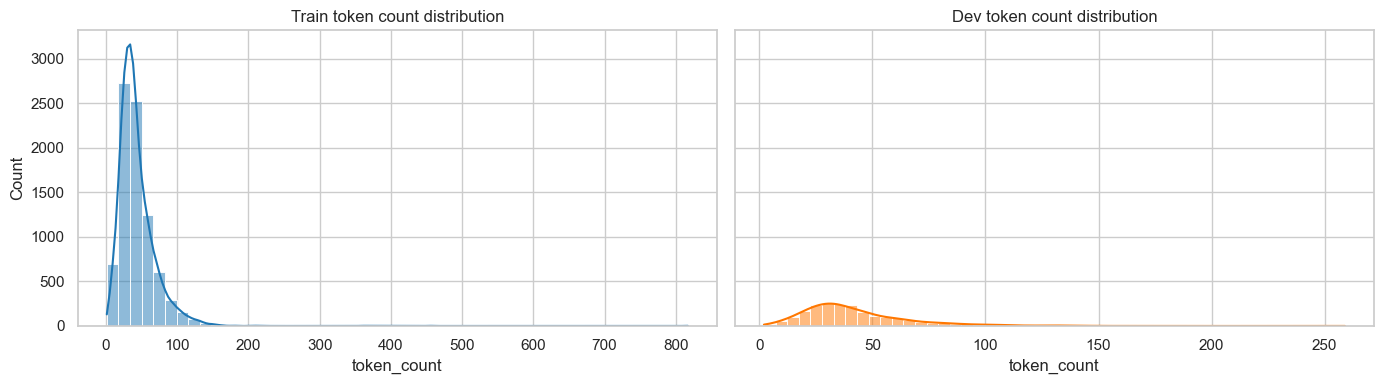

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

sns.histplot(train_df['token_count'], bins=50, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Train token count distribution')

sns.histplot(dev_df['token_count'], bins=50, kde=True, ax=axes[1], color="#ff7700")
axes[1].set_title('Dev token count distribution')

plt.tight_layout()
plt.show()


#### 1.2 Vocab Size

In [23]:
train_vocab = set(t for toks in train_df['tokens'] for t in toks)
dev_vocab = set(t for toks in dev_df['tokens'] for t in toks)

pd.DataFrame({
    'split': ['train', 'dev', 'union', 'overlap(train,dev)'],
    'vocab_size': [
        len(train_vocab),
        len(dev_vocab),
        len(train_vocab | dev_vocab),
        len(train_vocab & dev_vocab),
    ]
})


,split,vocab_size
0,train,26503
1,dev,12241
2,union,29658
3,"overlap(train,dev)",9086


#### 1.3 Class Distribution 

In [24]:
def class_dist(df, split):
    counts = df['label_binary'].value_counts().sort_index()
    total = counts.sum()
    return pd.DataFrame({
        'split': split,
        'label_binary': counts.index,
        'count': counts.values,
        'percentage': (counts.values / total * 100).round(2),
    })

class_df = pd.concat([class_dist(train_df, 'train'), class_dist(dev_df, 'dev')], ignore_index=True)
class_df


,split,label_binary,count,percentage
0,train,0,7581,90.52
1,train,1,794,9.48
2,dev,0,1894,90.49
3,dev,1,199,9.51


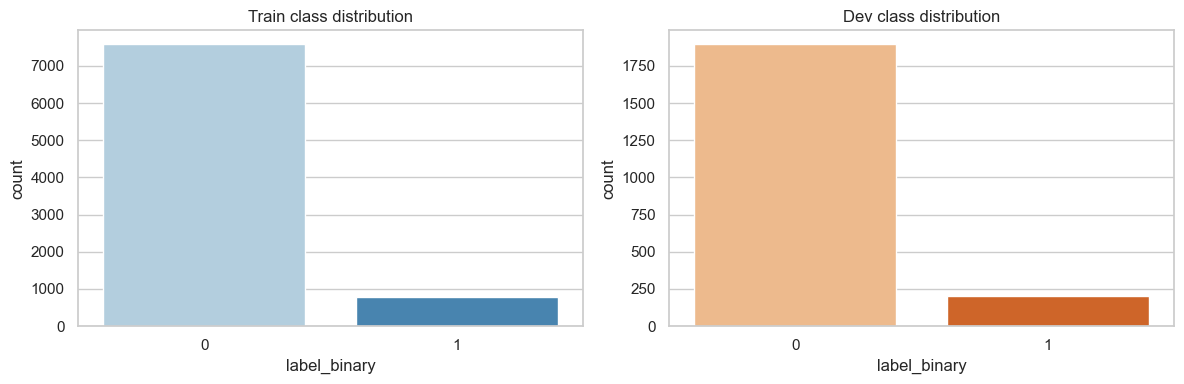

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=train_df, x='label_binary', hue='label_binary', ax=axes[0], palette='Blues', legend=False)
axes[0].set_title('Train class distribution')

sns.countplot(data=dev_df, x='label_binary', hue='label_binary', ax=axes[1], palette='Oranges', legend=False)
axes[1].set_title('Dev class distribution')

plt.tight_layout()
plt.show()


### 2. Lexical Analysis
- N-grams
- Stopword Density
- Word Frequency and Word Clouds


#### 2.1 N-grams

In [26]:
from functools import partial
def top_ngrams(texts, ngram_range=(1,1), top_k=20, remove_stopwords=False):
    sw = 'english' if remove_stopwords else None
    eda_tokenize = partial(nltk_tokenize, collapse_possessive=True)
    vec = CountVectorizer(
        tokenizer=eda_tokenize,
        token_pattern=None,
        lowercase=False,
        stop_words=sw,
        ngram_range=ngram_range,
        min_df=2,
    )
    X = vec.fit_transform(texts)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    grams = np.array(vec.get_feature_names_out())
    idx = np.argsort(freqs)[::-1][:top_k]
    return pd.DataFrame({'ngram': grams[idx], 'count': freqs[idx]})

print('Top bigrams (train)')
display(top_ngrams(train_df['text'], (2,2), 20, True))

print('Top trigrams (train)')
display(top_ngrams(train_df['text'], (3,3), 20, True))


Top bigrams (train)


,ngram,count
0,poor families,725
1,illegal immigrants,241
2,united states,135
3,u s,129
4,homeless people,109
5,year old,106
6,disabled people,104
7,people need,96
8,sri lanka,93
9,men women,91


Top trigrams (train)


,ngram,count
0,children poor families,67
1,president donald trump,44
2,students poor families,28
3,come poor families,24
4,world war ii,15
5,president barack obama,14
6,h email friend,14
7,help poor families,14
8,refugees asylum seekers,14
9,need humanitarian assistance,13


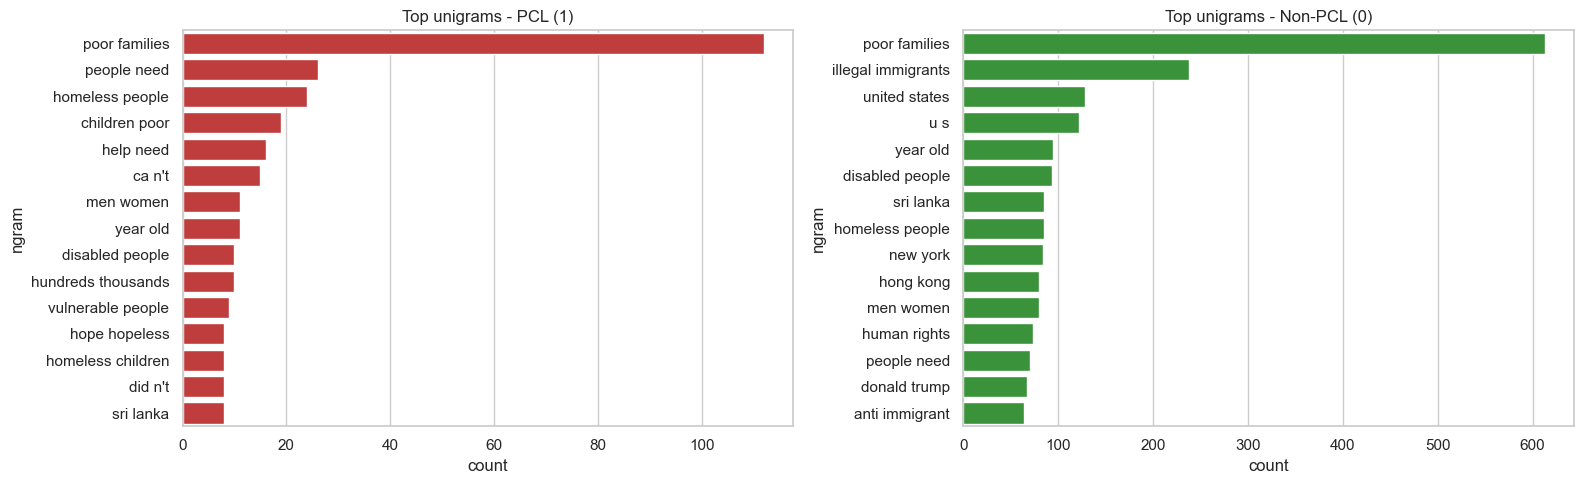

In [35]:
pos = train_df.loc[train_df['label_binary']==1, 'text']
neg = train_df.loc[train_df['label_binary']==0, 'text']

pos_top = top_ngrams(pos, (2,2), 15, True)
neg_top = top_ngrams(neg, (2,2), 15, True)

fig, axes = plt.subplots(1,2, figsize=(16,5))
sns.barplot(data=pos_top, y='ngram', x='count', ax=axes[0], color='#d62728')
axes[0].set_title('Top unigrams - PCL (1)')

sns.barplot(data=neg_top, y='ngram', x='count', ax=axes[1], color='#2ca02c')
axes[1].set_title('Top unigrams - Non-PCL (0)')

plt.tight_layout()
plt.show()


#### 2.2 StopWord Density

In [36]:
def stopword_density(tokens):
    if not tokens:
        return 0.0
    return sum(1 for t in tokens if t in EN_STOPWORDS) / len(tokens)

for df in (train_df, dev_df):
    df['stopword_density'] = df['tokens'].apply(stopword_density)

pd.DataFrame({
    'split': ['train', 'dev'],
    'mean_stopword_density': [train_df['stopword_density'].mean(), dev_df['stopword_density'].mean()],
    'median_stopword_density': [train_df['stopword_density'].median(), dev_df['stopword_density'].median()],
})


,split,mean_stopword_density,median_stopword_density
0,train,0.420652,0.423077
1,dev,0.418626,0.421053


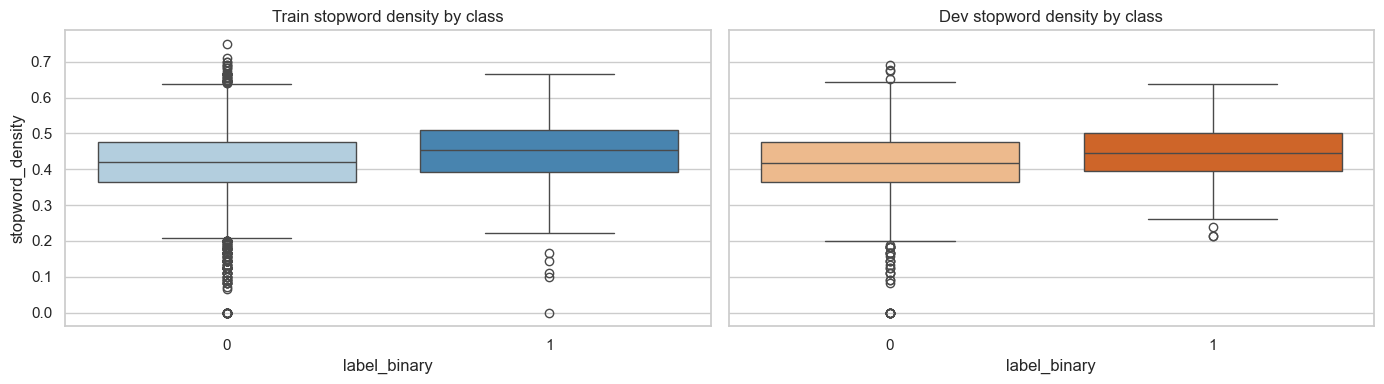

In [37]:
fig, axes = plt.subplots(1,2, figsize=(14,4), sharey=True)

sns.boxplot(data=train_df, x='label_binary', y='stopword_density', hue='label_binary', legend=False, ax=axes[0], palette='Blues')
axes[0].set_title('Train stopword density by class')

sns.boxplot(data=dev_df, x='label_binary', y='stopword_density', hue='label_binary', legend=False, ax=axes[1], palette='Oranges')
axes[1].set_title('Dev stopword density by class')

plt.tight_layout()
plt.show()


#### 2.3 Word Frequency and Word Clouds

In [41]:
def build_freq(tokens_series, remove_stopwords=True):
    c = Counter()
    for toks in tokens_series:
        if remove_stopwords:
            toks = [t for t in toks if t not in EN_STOPWORDS]
        c.update(toks)
    return c

all_freq = build_freq(train_df['tokens'])
pos_freq = build_freq(train_df.loc[train_df['label_binary']==1, 'tokens'])
neg_freq = build_freq(train_df.loc[train_df['label_binary']==0, 'tokens'])

freq_df = pd.DataFrame(all_freq.most_common(30), columns=['token','count'])
freq_df.head(20)


,token,count
0,said,1748
1,people,1505
2,women,1311
3,need,1069
4,families,1056
5,immigrants,1029
6,vulnerable,973
7,poor,957
8,disabled,915
9,homeless,820


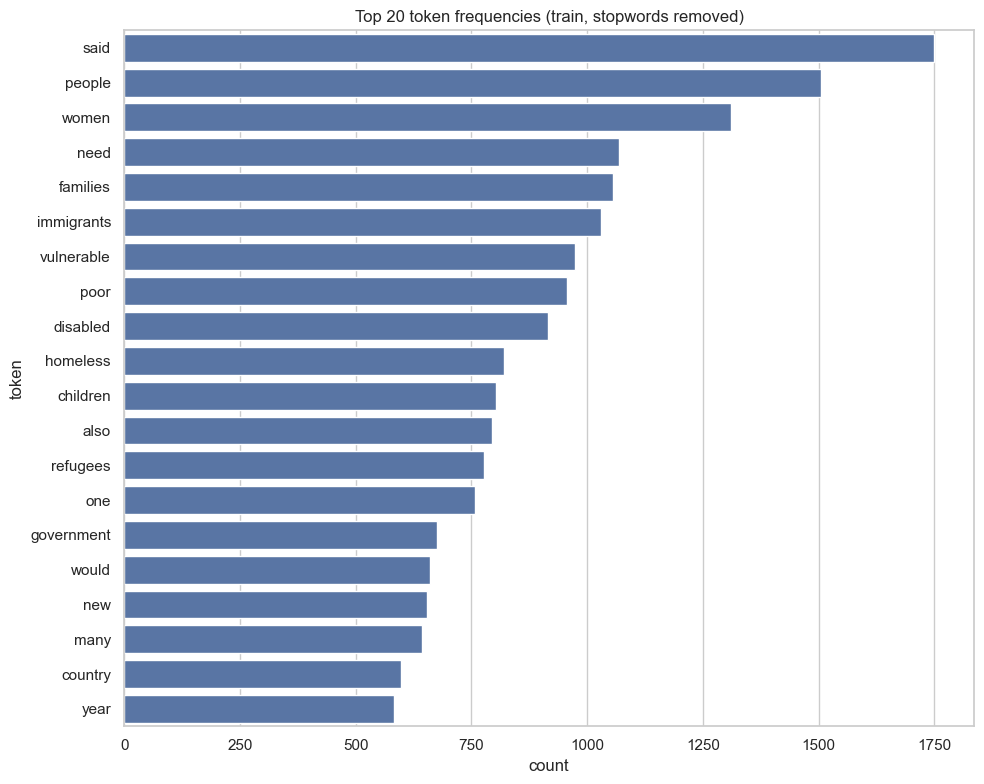

In [42]:
plt.figure(figsize=(10,8))
sns.barplot(data=freq_df.head(20), y='token', x='count', color='#4c72b0')
plt.title('Top 20 token frequencies (train, stopwords removed)')
plt.tight_layout()
plt.show()


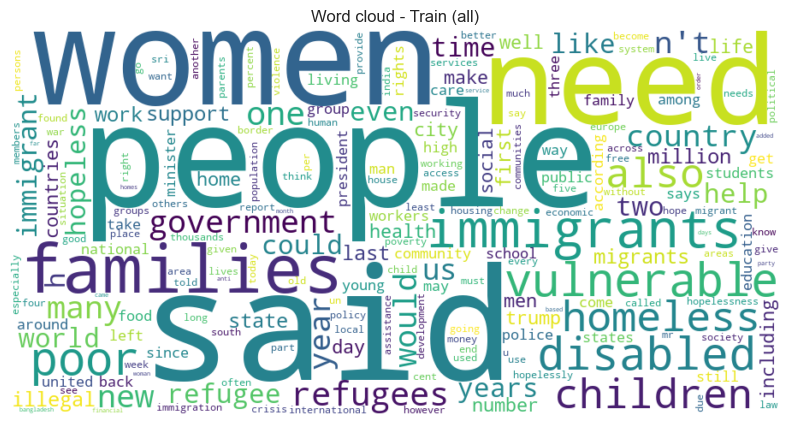

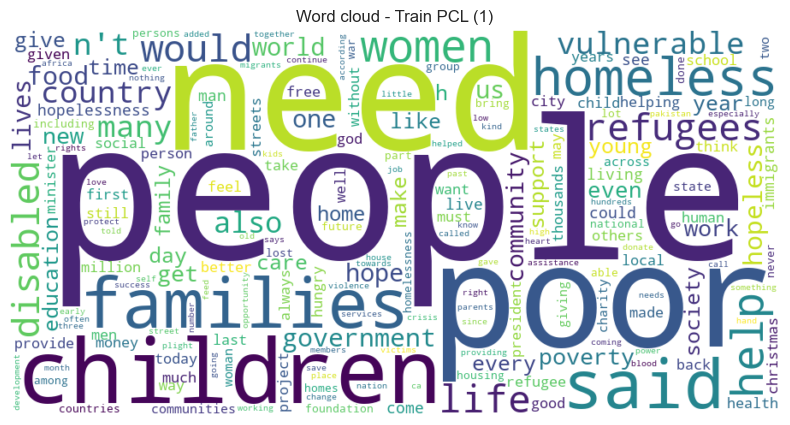

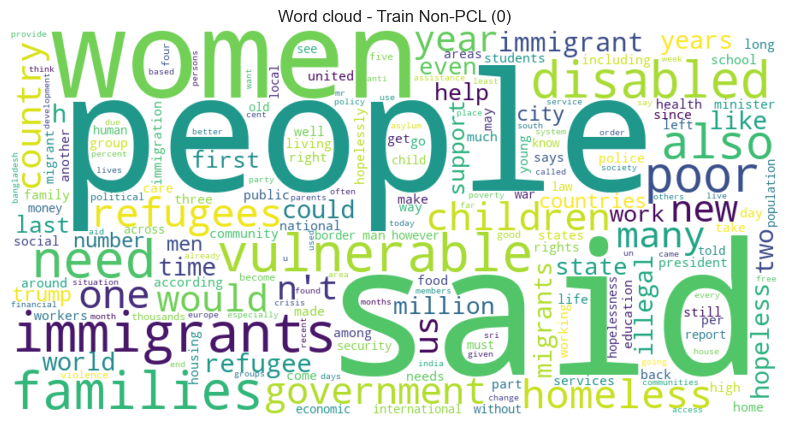

In [43]:
def show_wordcloud(freq, title):
    wc = WordCloud(width=900, height=450, background_color='white', max_words=200, colormap='viridis')
    wc = wc.generate_from_frequencies(dict(freq))
    plt.figure(figsize=(12,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

show_wordcloud(all_freq, 'Word cloud - Train (all)')
show_wordcloud(pos_freq, 'Word cloud - Train PCL (1)')
show_wordcloud(neg_freq, 'Word cloud - Train Non-PCL (0)')


### 3. t-SNE Cluster View
Pipeline: TF-IDF -> t-SNE


In [44]:
RANDOM_STATE = 42
MAX_PER_CLASS = 1200

train_pos = train_df[train_df['label_binary'] == 1]
train_neg = train_df[train_df['label_binary'] == 0]

sample_df = pd.concat([
    train_pos.sample(min(len(train_pos), MAX_PER_CLASS), random_state=RANDOM_STATE),
    train_neg.sample(min(len(train_neg), MAX_PER_CLASS), random_state=RANDOM_STATE),
], ignore_index=True)

print('t-SNE sample shape:', sample_df.shape)
print(sample_df['label_binary'].value_counts())


t-SNE sample shape: (1994, 10)
label_binary
0    1200
1     794
Name: count, dtype: int64


In [45]:
tfidf = TfidfVectorizer(
    tokenizer=nltk_tokenize,
    token_pattern=None,
    lowercase=False,
    stop_words='english',
    ngram_range=(1,2),
    min_df=3,
    max_features=12000,
)
X = tfidf.fit_transform(sample_df['text'])

svd = TruncatedSVD(n_components=80, random_state=RANDOM_STATE)
X_reduced = svd.fit_transform(X)

tsne = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    perplexity=35,
    learning_rate='auto',
    init='pca',
    max_iter=1200,
)

X_tsne = tsne.fit_transform(X_reduced)
plot_df = pd.DataFrame({
    'tsne_1': X_tsne[:,0],
    'tsne_2': X_tsne[:,1],
    'label_binary': sample_df['label_binary'].values,
})
plot_df.head()


,tsne_1,tsne_2,label_binary
0,-9.543605,-1.025119,1
1,42.946079,3.300830,1
2,-0.580620,40.758675,1
3,-4.131441,9.496042,1
4,-3.931667,9.429077,1


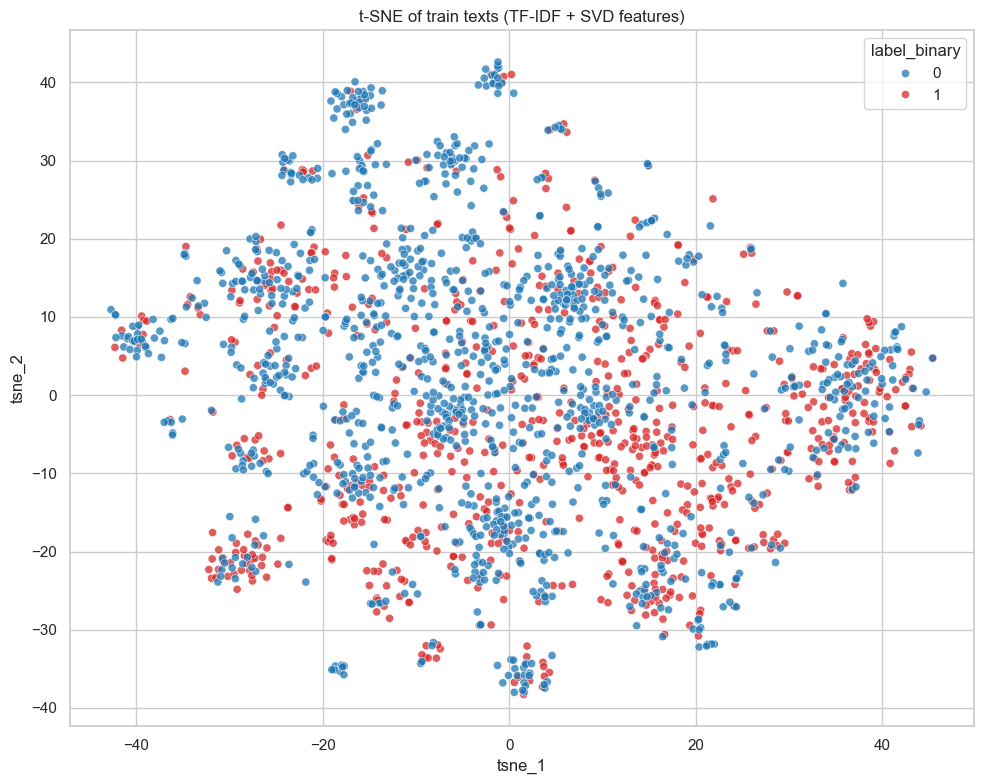

In [46]:
plt.figure(figsize=(10,8))
sns.scatterplot(
    data=plot_df,
    x='tsne_1',
    y='tsne_2',
    hue='label_binary',
    palette={0:'#1f77b4', 1:'#d62728'},
    alpha=0.75,
    s=35,
)
plt.title('t-SNE of train texts (TF-IDF + SVD features)')
plt.tight_layout()
plt.show()


### Summary
- Strong class imbalance is visible.
- Lexical cues exist but overlap is high.
- t-SNE helps inspect local structure but should not be treated as strict evidence of separability.
